In [58]:
import json

import numpy as np


def load_binary(filename: str) -> bytes:
    data = open(filename, "rb").read()
    # return np.frombuffer(data, dtype=np.uint8)
    return data


data_all_ones = load_binary("all_ones.bin")
data_all_zeros = load_binary("all_zeros.bin")
data_half_zeros_half_ones = load_binary("half_zeros_half_ones.bin")
data_ramp = load_binary("ramp.bin")
data_toggle = load_binary("toggle.bin")

config = json.load(open("config.json"))

In [59]:
assert len(data_all_ones) == len(data_all_zeros) == len(data_half_zeros_half_ones) == len(data_ramp) == len(data_toggle)

num_bytes = len(data_all_ones)

num_bytes

80040

In [60]:
fifo_depth = config["fpga"]["fifo_depth"]
num_shots = config["fpga"]["num_shots"]
num_frames = config["num_frames"]
lvds_lanes = config["fpga"]["lvds_lanes"]

fifo_depth, num_shots, num_frames, lvds_lanes

(2048, 10, 1, [0])

In [75]:
bytes_per_shot = fifo_depth * 2 * 10 / 8 * len(lvds_lanes)

bytes_per_shot, bytes_per_shot * num_shots * num_frames

(5120.0, 51200.0)

In [81]:
np.unpackbits(np.frombuffer(data_all_ones, dtype=np.uint8), axis=-1, bitorder='big').reshape((len(lvds_lanes), -1))

array([[0, 0, 0, ..., 1, 1, 1]], shape=(1, 640320), dtype=uint8)

In [62]:
def hexdump(data: np.ndarray | bytes):
    for i in range(0, len(data), 16):
        chunk = data[i:i+16]
        hex_bytes = ' '.join(f'{b:02X}' for b in chunk)
        ascii_bytes = ''.join((chr(b) if 32 <= b < 127 else '.') for b in chunk)
        print(f'{i:08X}  {hex_bytes:<48}  |{ascii_bytes}|')

print("All Ones:")
hexdump(data_all_ones[3190*10//8:3210*10//8])
print("All Zeros:")
hexdump(data_all_zeros[3190*10//8:3210*10//8])
print("Half Zeros Half Ones:")
hexdump(data_half_zeros_half_ones[3190*10//8:3210*10//8])
print("Ramp:")
hexdump(data_ramp[3190*10//8:3210*10//8])
print("Toggle:")
hexdump(data_toggle[3190*10//8:3210*10//8])

All Ones:
00000000  FF FF FF FF FF FF FF FF FF FF FF FF FF FF FF 00   |................|
00000010  00 FF FF FF FF FF FF FF FF                        |.........|
All Zeros:
00000000  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00   |................|
00000010  00 00 00 00 00 00 00 00 00                        |.........|
Half Zeros Half Ones:
00000000  E0 F8 3E 0F 83 E0 F8 3E 0F 83 E0 F8 3E 0F 83 00   |..>....>....>...|
00000010  00 E0 F8 3E 0F 83 E0 F8 3E                        |...>....>|
Ramp:
00000000  6D 1B 06 F1 B8 71 1C 07 31 C8 75 1D 07 71 D8 00   |m....q..1.u..q..|
00000010  00 79 1E 07 B1 E8 7D 1F 07                        |.y....}..|
Toggle:
00000000  00 FF C0 0F FC 00 FF C0 0F FC 00 FF C0 0F FC 00   |................|
00000010  00 00 FF C0 0F FC 00 FF C0                        |.........|


In [63]:
# print(f"{0xE0:08b}{0xF8:08b}{0x3E:08b}{0x0F:08b}{0x83:08b}")
print(f"{0xF8:08b}{0x3E:08b}{0x0F:08b}{0x83:08b}{0xE0:08b}")

1111100000111110000011111000001111100000


C:\Users\cedr0\AppData\Local\Temp\ipykernel_42480\2454216574.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12, 8))


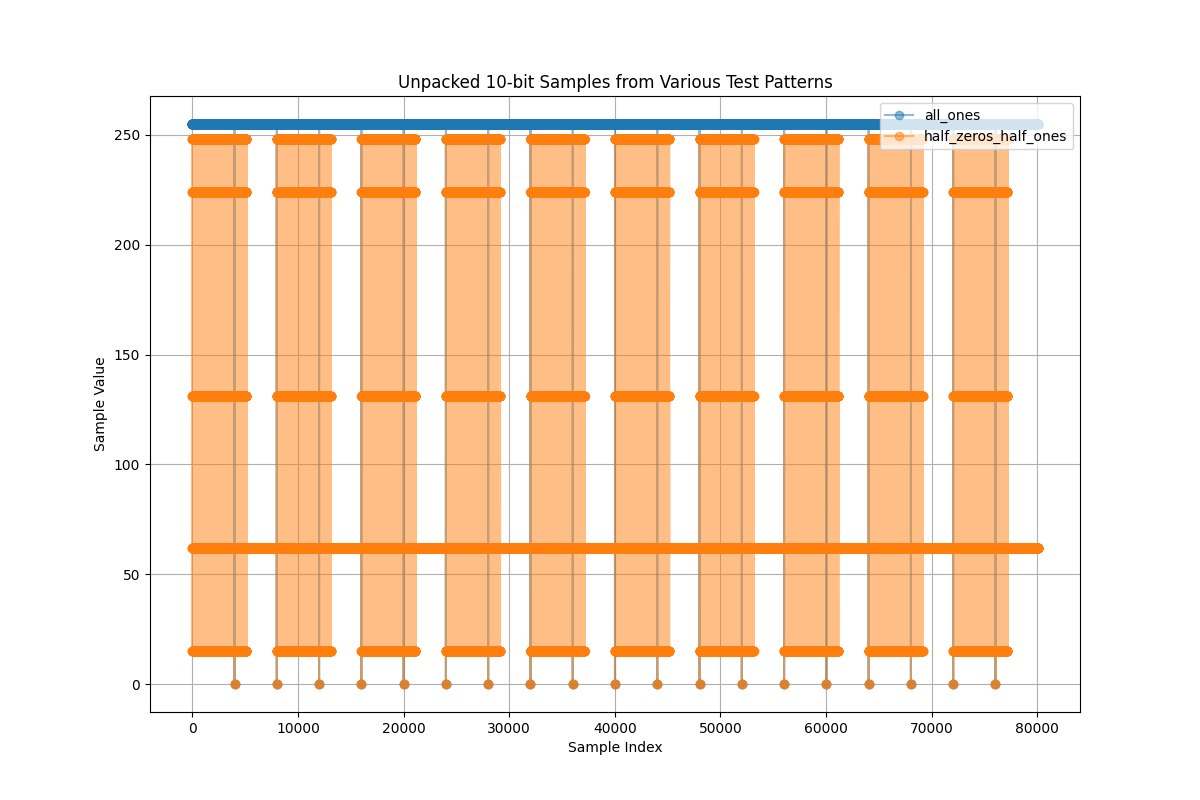

In [64]:
import matplotlib.pyplot as plt
%matplotlib widget

INTERVAL = 3200 * 8 // 10  # samples to bytes
PLOT_IDX = 0

plt.figure(figsize=(12, 8))

for name, data in [
    ("all_ones", data_all_ones),
    # ("all_zeros", data_all_zeros),
    ("half_zeros_half_ones", data_half_zeros_half_ones),
    # ("ramp", data_ramp),
    # ("toggle", data_toggle),
]:
    plt.plot(np.frombuffer(data, dtype=np.uint8)[3:], 'o-', label=name, alpha=0.5)

plt.title("Unpacked 10-bit Samples from Various Test Patterns")
plt.xlabel("Sample Index")
plt.ylabel("Sample Value")
# plt.xlim(INTERVAL*PLOT_IDX - 10, INTERVAL*PLOT_IDX + 10)
plt.legend(loc='upper right')
plt.grid()
plt.show()

In [65]:
def unpack_10bit(data: bytes, bit_order: str = 'msb', signed: bool = False) -> 'np.ndarray':
    """Unpack a stream of bytes containing packed 10-bit samples.
    Parameters:
    - data: raw bytes containing consecutive 10-bit samples packed back-to-back.
    - bit_order: 'lsb' if bytes are little-endian-packed (LSB-first across the stream),
                 'msb' if bits are MSB-first across the stream.
    - signed: if True, interpret 10-bit samples as signed two's-complement values.

    Returns a NumPy array of dtype int16 (or uint16 when signed=False).
    """
    import numpy as _np

    if bit_order not in ('lsb', 'msb'):
        raise ValueError("bit_order must be 'lsb' or 'msb'")

    mask = (1 << 10) - 1
    out = []

    if bit_order == 'lsb':
        # Accumulate little-endian (LSB-first) stream: each incoming byte adds to low bits of buffer
        buf = 0
        bits = 0
        for b in data:
            buf |= (b & 0xFF) << bits
            bits += 8
            while bits >= 10:
                sample = buf & mask
                out.append(sample)
                buf >>= 10
                bits -= 10
    else:
        # MSB-first: shift buffer left and append new byte at low end
        buf = 0
        bits = 0
        for b in data:
            buf = (buf << 8) | (b & 0xFF)
            bits += 8
            while bits >= 10:
                shift = bits - 10
                sample = (buf >> shift) & mask
                out.append(sample)
                buf &= (1 << shift) - 1 if shift > 0 else 0
                bits -= 10

    arr = _np.array(out, dtype=_np.int16 if signed else _np.uint16)
    if signed:
        # convert from 10-bit two's complement to signed integer
        sign_bit = 1 << 9
        neg_mask = (1 << 10) - 1
        arr = _np.where(arr & sign_bit, arr - (1 << 10), arr).astype(_np.int16)
    return arr

# Demonstrate on the loaded sample files (use 'lsb' or 'msb' depending on your packing)
for name, data in [
    ("all_ones", data_all_ones),
    ("all_zeros", data_all_zeros),
    ("half_zeros_half_ones", data_half_zeros_half_ones),
    ("ramp", data_ramp),
    ("toggle", data_toggle),
]:
    samples = unpack_10bit(data[3:], bit_order='msb', signed=False)
    print(f'File: {name} - bytes={len(data)} samples={len(samples)}')
    print('  first 20 samples:', samples[3190:3210].tolist())
    print()


File: all_ones - bytes=80040 samples=64029
  first 20 samples: [1023, 1023, 1023, 1023, 1023, 1023, 1023, 1023, 1023, 768, 3, 1023, 1023, 1023, 1023, 1023, 1023, 1023, 1023, 1023]

File: all_zeros - bytes=80040 samples=64029
  first 20 samples: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

File: half_zeros_half_ones - bytes=80040 samples=64029
  first 20 samples: [992, 992, 992, 992, 992, 992, 992, 992, 992, 768, 3, 527, 527, 527, 527, 527, 527, 527, 527, 527]

File: ramp - bytes=80040 samples=64029
  first 20 samples: [110, 113, 112, 115, 114, 117, 116, 119, 118, 0, 1, 913, 897, 945, 929, 977, 961, 1009, 994, 18]

File: toggle - bytes=80040 samples=64029
  first 20 samples: [1023, 0, 1023, 0, 1023, 0, 1023, 0, 1023, 0, 0, 15, 1008, 15, 1008, 15, 1008, 15, 1008, 15]



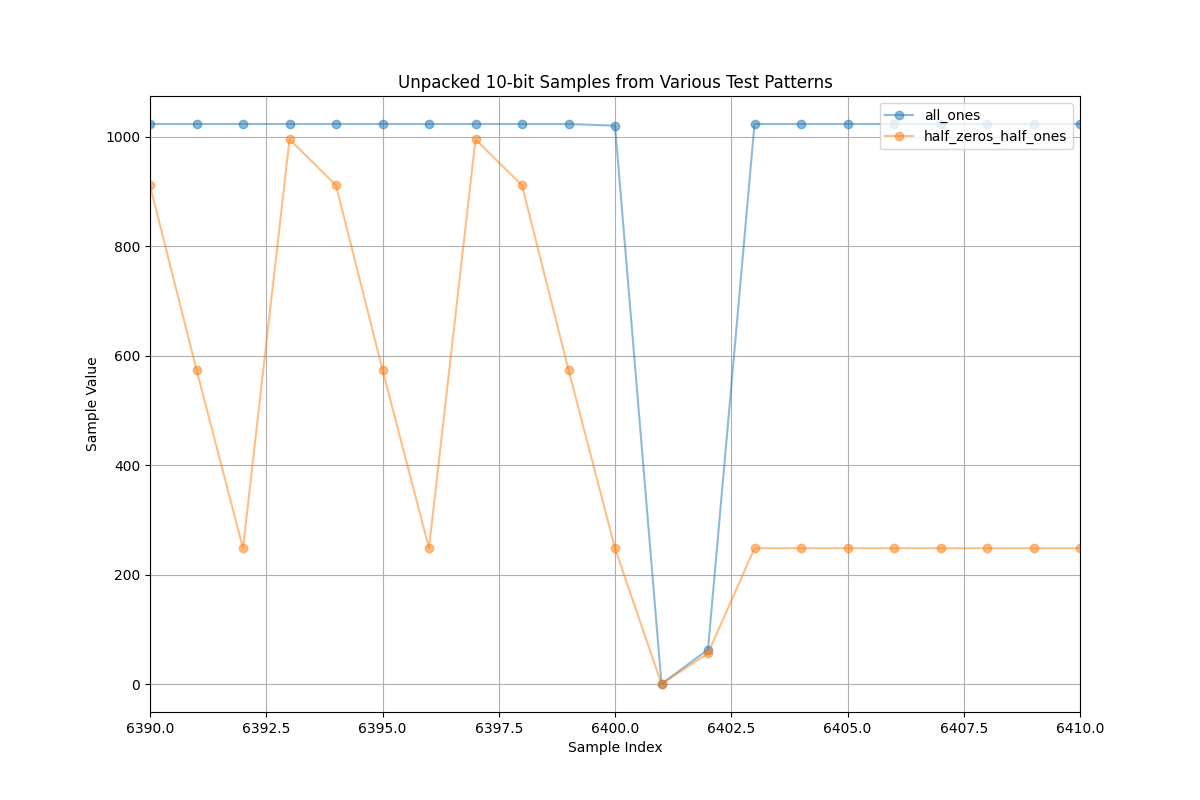

In [66]:
INTERVAL = 3200
PLOT_IDX = 2

plt.figure(figsize=(12, 8))

for name, data in [
    ("all_ones", data_all_ones),
    # ("all_zeros", data_all_zeros),
    ("half_zeros_half_ones", data_half_zeros_half_ones),
    # ("ramp", data_ramp),
    # ("toggle", data_toggle),
]:
    samples = unpack_10bit(data[3:], bit_order='msb', signed=False)
    plt.plot(samples, 'o-', label=name, alpha=0.5)

plt.title("Unpacked 10-bit Samples from Various Test Patterns")
plt.xlabel("Sample Index")
plt.ylabel("Sample Value")
plt.xlim(INTERVAL*PLOT_IDX - 10, INTERVAL*PLOT_IDX + 10)
plt.legend(loc='upper right')
plt.grid()
plt.show()

Initilal length of byte array:  80040
Aligned  length of byte array:  5120
Shape of bit array:  (1, 40960)
Trimmed shape of bit array:  (1, 40960)
Cut from the start n samples, n = :  1
Cut from the end n samples, n = :  0
Bit slip corrected number of bits per lane:  40940
N of acquired samples:  2047
Initilal length of byte array:  80040
Aligned  length of byte array:  5120
Shape of bit array:  (1, 40960)
Trimmed shape of bit array:  (1, 40960)
Cut from the start n samples, n = :  1
Cut from the end n samples, n = :  0
Bit slip corrected number of bits per lane:  40940
N of acquired samples:  2047


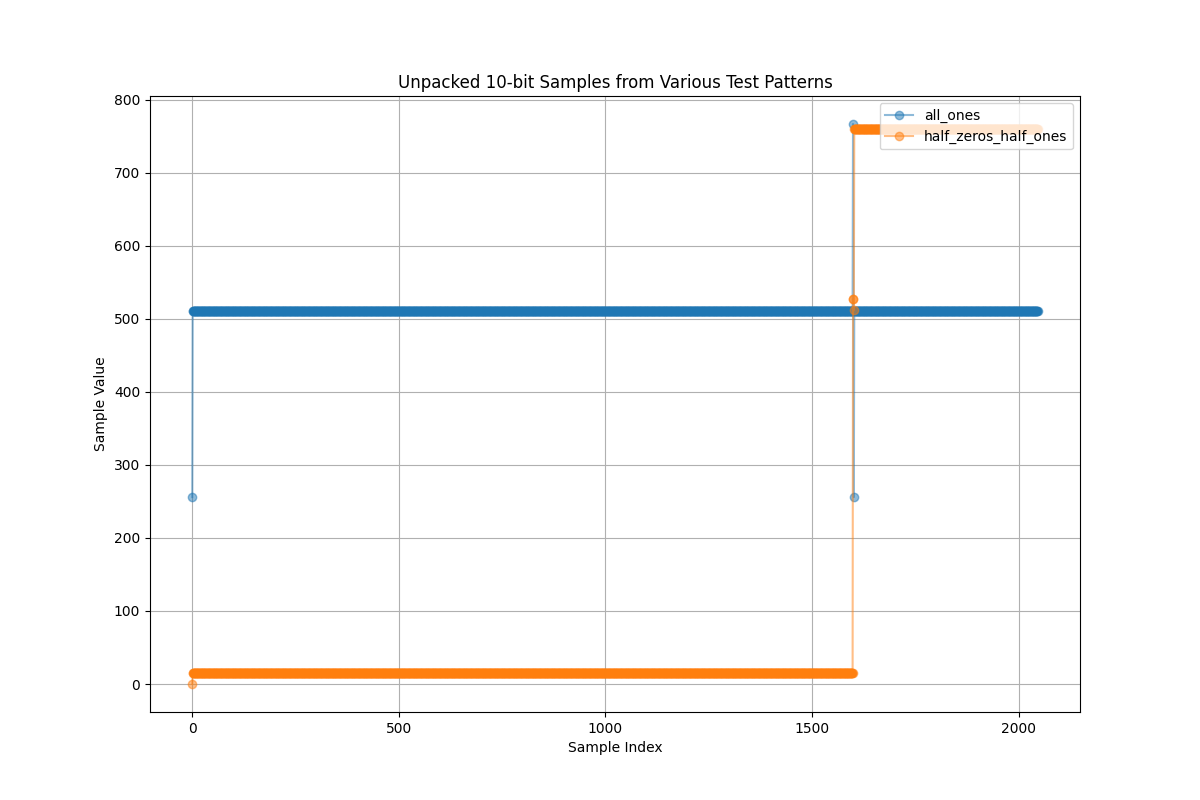

In [82]:
from parser import parse_bitstream

plt.figure(figsize=(12, 8))

for name, data in [
    ("all_ones", data_all_ones),
    # ("all_zeros", data_all_zeros),
    ("half_zeros_half_ones", data_half_zeros_half_ones),
    # ("ramp", data_ramp),
    # ("toggle", data_toggle),
]:
    samples = parse_bitstream(data, dbg_msgs=True, read_size_samples=fifo_depth, n_activ_ch=len(lvds_lanes)*2)
    plt.plot(samples[0], 'o-', label=name, alpha=0.5)

plt.title("Unpacked 10-bit Samples from Various Test Patterns")
plt.xlabel("Sample Index")
plt.ylabel("Sample Value")
# plt.xlim(3100, 3300)
plt.legend(loc='upper right')
plt.grid()
plt.show()